<a href="https://colab.research.google.com/github/OrastaRakhmatullayeva/ML-projects/blob/main/mini_project_student_performance_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
!pip install opendatasets

In [49]:
import opendatasets as od
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


Step 1 — Load & Inspect

In [50]:
od.download("https://www.kaggle.com/competitions/student-performance-prediction-machine-learning-challenge/data")

Skipping, found downloaded files in "./student-performance-prediction-machine-learning-challenge" (use force=True to force download)


In [51]:
df=pd.read_csv('/content/student-performance-prediction-machine-learning-challenge/train.csv')

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     16000 non-null  int64  
 1   student_id             16000 non-null  int64  
 2   age                    16000 non-null  int64  
 3   gender                 16000 non-null  object 
 4   study_hours_per_day    16000 non-null  float64
 5   sleep_hours            16000 non-null  float64
 6   phone_usage_hours      16000 non-null  float64
 7   social_media_hours     16000 non-null  float64
 8   youtube_hours          16000 non-null  float64
 9   gaming_hours           16000 non-null  float64
 10  breaks_per_day         16000 non-null  int64  
 11  coffee_intake_mg       16000 non-null  int64  
 12  exercise_minutes       16000 non-null  int64  
 13  assignments_completed  16000 non-null  int64  
 14  attendance_percentage  16000 non-null  float64
 15  st

In [53]:
df.describe()

,id,student_id,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,10006.506875,10007.506875,23.020937,5.254446,6.515254,6.258692,3.995989,2.985526,2.976373,7.539625,249.035250,59.832125,9.492313,69.894694,5.478813,64.430375,70.377071,50.146637
std,5790.786923,5790.786923,3.753283,2.743874,2.033761,3.305756,2.311722,1.731141,1.733127,4.017236,143.732208,34.676427,5.781352,17.408698,2.867785,20.226804,17.293340,16.095733
min,1.000000,2.000000,17.000000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,4993.750000,4994.750000,20.000000,2.890000,4.760000,3.390000,2.000000,1.480000,1.477500,4.000000,124.000000,30.000000,4.000000,54.740000,3.000000,47.000000,55.617500,38.657500
50%,10020.500000,10021.500000,23.000000,5.250000,6.520000,6.230000,3.990000,2.970000,2.950000,8.000000,248.000000,60.000000,9.000000,69.865000,5.000000,65.000000,70.545000,50.220000
75%,15029.250000,15030.250000,26.000000,7.632500,8.320000,9.100000,5.970000,4.480000,4.490000,11.000000,372.000000,90.000000,15.000000,85.020000,8.000000,82.000000,85.480000,61.840000
max,19999.000000,20000.000000,29.000000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,100.000000,10.000000,99.000000,99.990000,100.000000


In [54]:
df.head()

,id,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,5894,5895,28,Other,4.56,7.61,1.70,7.23,3.80,3.18,2,256,102,14,52.72,6,68,70.48,55.29
1,3728,3729,18,Female,7.95,8.17,4.24,5.50,4.80,3.53,9,370,115,17,87.51,1,69,57.67,78.68
2,8958,8959,19,Male,6.06,9.02,3.17,5.08,5.09,3.74,5,250,33,9,72.39,8,57,72.51,60.66
3,7671,7672,21,Female,1.40,8.06,2.35,1.03,0.13,5.23,4,55,110,0,87.47,5,34,81.93,37.51
4,5999,6000,25,Male,9.27,7.39,10.68,5.21,3.43,5.38,11,436,66,17,47.66,5,37,49.11,50.72


In [55]:
df.isnull().sum().sort_values(ascending=False).head()

,0
id,0
student_id,0
age,0
gender,0
study_hours_per_day,0


In [56]:
df.duplicated().sum()

np.int64(0)

Conclusion, in our dataset there are not any missing or duplicated values


STEP 2 DROPPING UNNECESSARY COLUMNS

In [57]:
df.drop(columns=['id', 'student_id'],inplace=True)

STEP 3 -> EDA

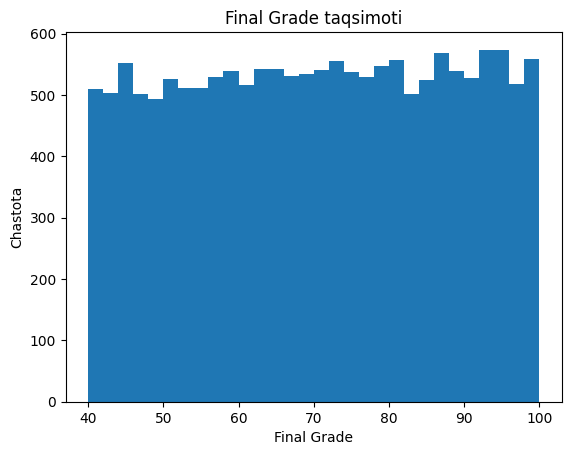

p-value: 6.015112072896218e-56


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 16000.
  res = hypotest_fun_out(*samples, **kwds)


In [58]:
plt.hist(df['final_grade'], bins=30)
plt.xlabel('Final Grade')
plt.ylabel('Chastota')
plt.title('Final Grade taqsimoti')
plt.show()

from scipy import stats
stat, p_value = stats.shapiro(df['final_grade'])
print(f"p-value: {p_value}")


"Shapiro-Wilk test natijasi (p < 0.001) final_grade normal taqsimotga ega emasligini ko'rsatdi. Histogram tahlili shuni tasdiqladiki, baholar 40-100 oralig'ida deyarli tekis (uniform) taqsimlangan, bu esa datasetning sun'iy (synthetic) tabiatidan dalolat berishi mumkin."


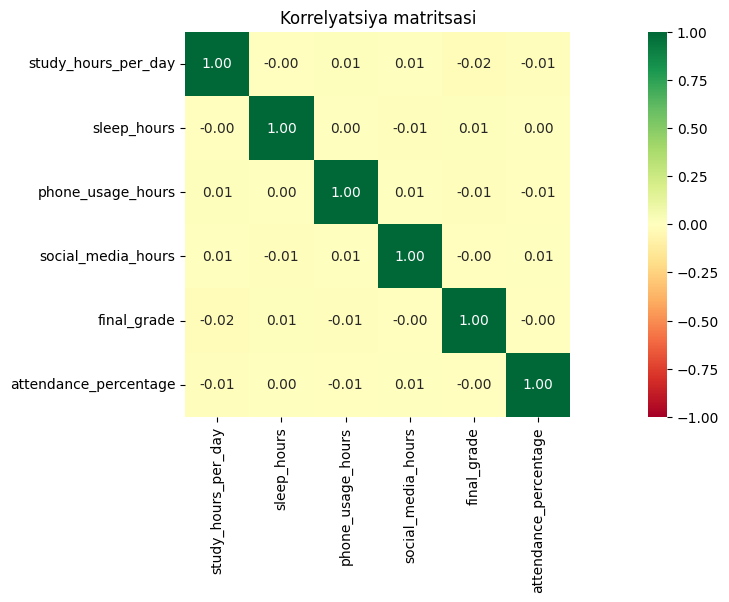

In [59]:
plt.figure(figsize=(20, 5))

number = df[['study_hours_per_day', 'sleep_hours',
            'phone_usage_hours', 'social_media_hours','final_grade',
             'attendance_percentage']]

corr = number.corr()

sns.heatmap(corr, annot=True,
    cmap='RdYlGn', vmin=-1, vmax=1,
    fmt='.2f', square=True)

plt.title('Korrelyatsiya matritsasi')
plt.show()

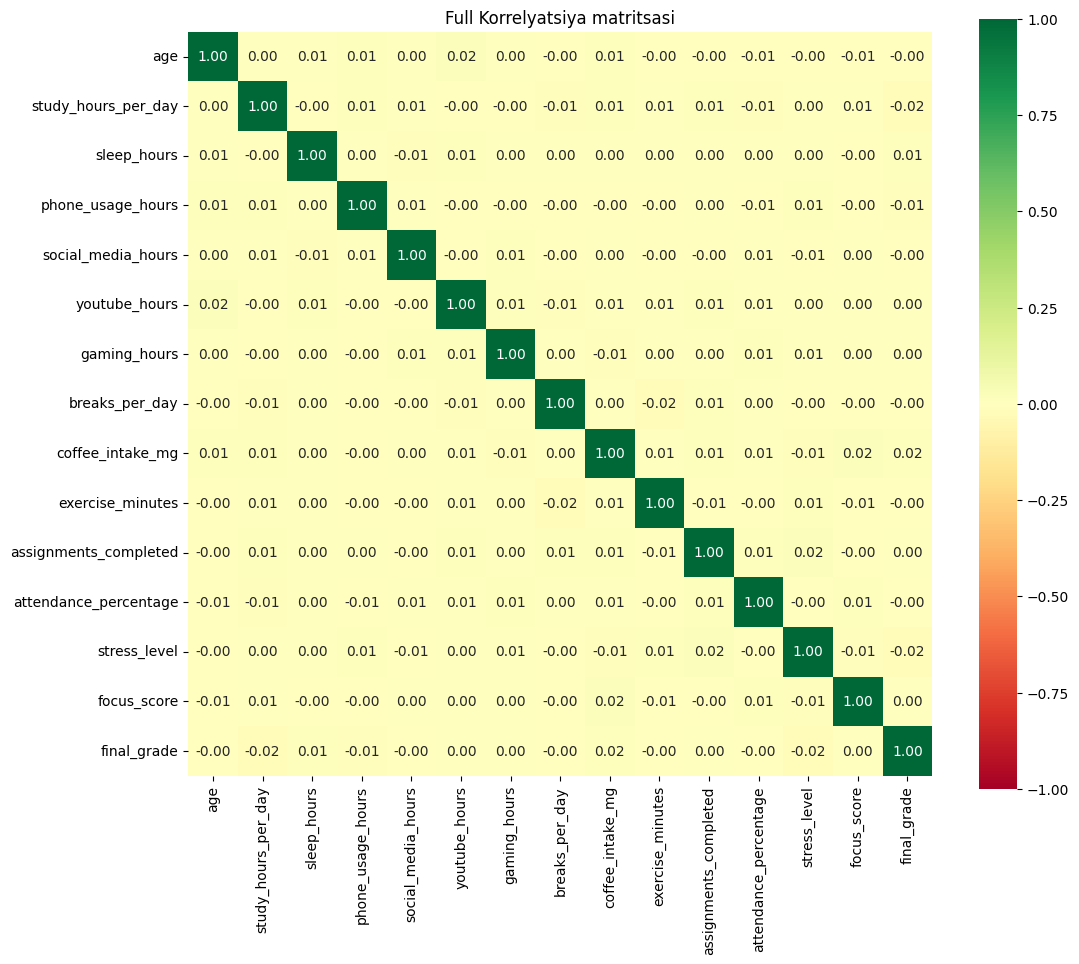

final_grade              1.000000
coffee_intake_mg         0.015340
sleep_hours              0.010663
focus_score              0.004009
gaming_hours             0.002491
assignments_completed    0.002368
youtube_hours            0.000953
breaks_per_day          -0.002025
social_media_hours      -0.002547
exercise_minutes        -0.002839
age                     -0.003767
attendance_percentage   -0.004882
phone_usage_hours       -0.014050
stress_level            -0.015878
study_hours_per_day     -0.016024
Name: final_grade, dtype: float64


In [60]:
# Full correlation matrix with all numeric columns
numeric_cols = ['age', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours',
                'social_media_hours', 'youtube_hours', 'gaming_hours',
                'breaks_per_day', 'coffee_intake_mg', 'exercise_minutes',
                'assignments_completed', 'attendance_percentage',
                'stress_level', 'focus_score', 'final_grade']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='RdYlGn', vmin=-1, vmax=1, fmt='.2f', square=True)
plt.title('Full Korrelyatsiya matritsasi')
plt.show()

print(corr['final_grade'].sort_values(ascending=False))

there is no relation between columns, maybe dataset built randomly numbers

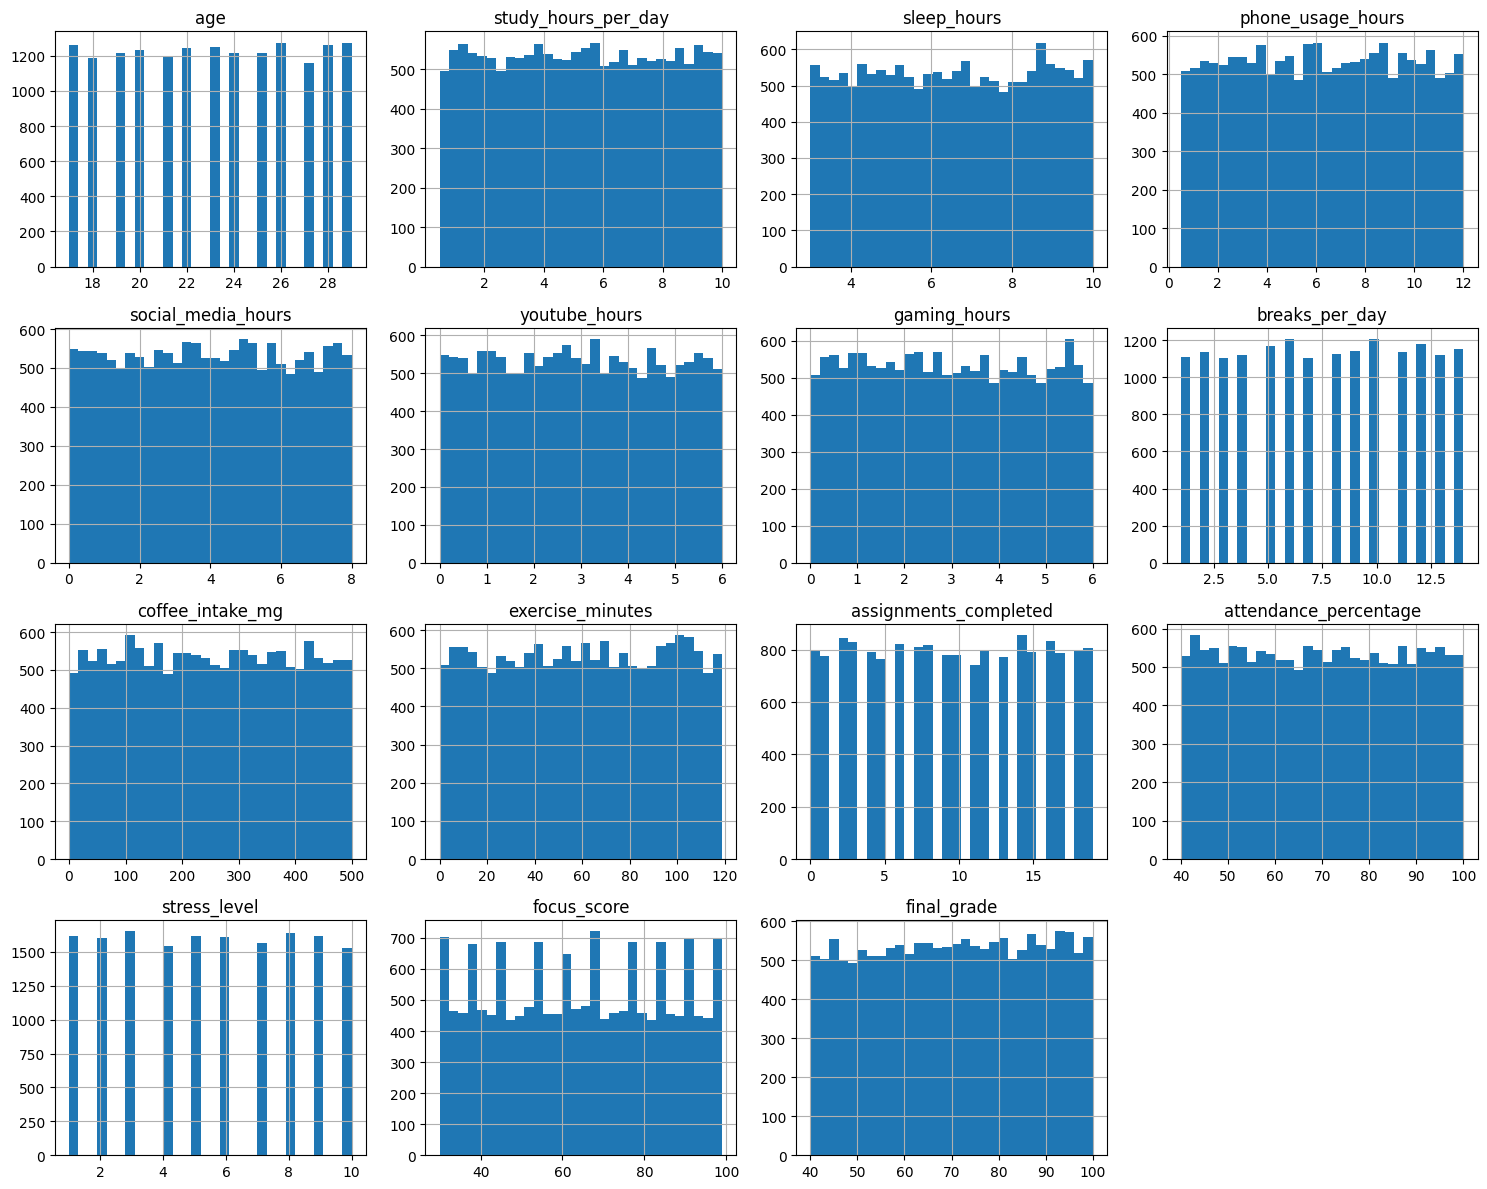

In [61]:
df[numeric_cols].hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

gender
Male      7704
Female    7683
Other      613
Name: count, dtype: int64


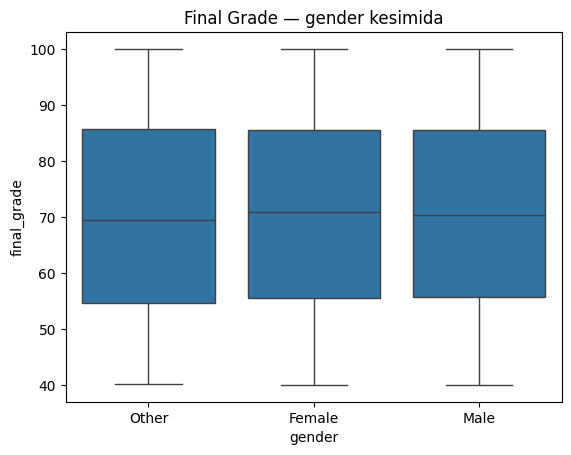

In [62]:
print(df['gender'].value_counts())

sns.boxplot(x='gender', y='final_grade', data=df)
plt.title('Final Grade — gender kesimida')
plt.show()

In [63]:
for col in ['coffee_intake_mg', 'assignments_completed', 'exercise_minutes']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} ta outlier")

coffee_intake_mg: 0 ta outlier
assignments_completed: 0 ta outlier
exercise_minutes: 0 ta outlier


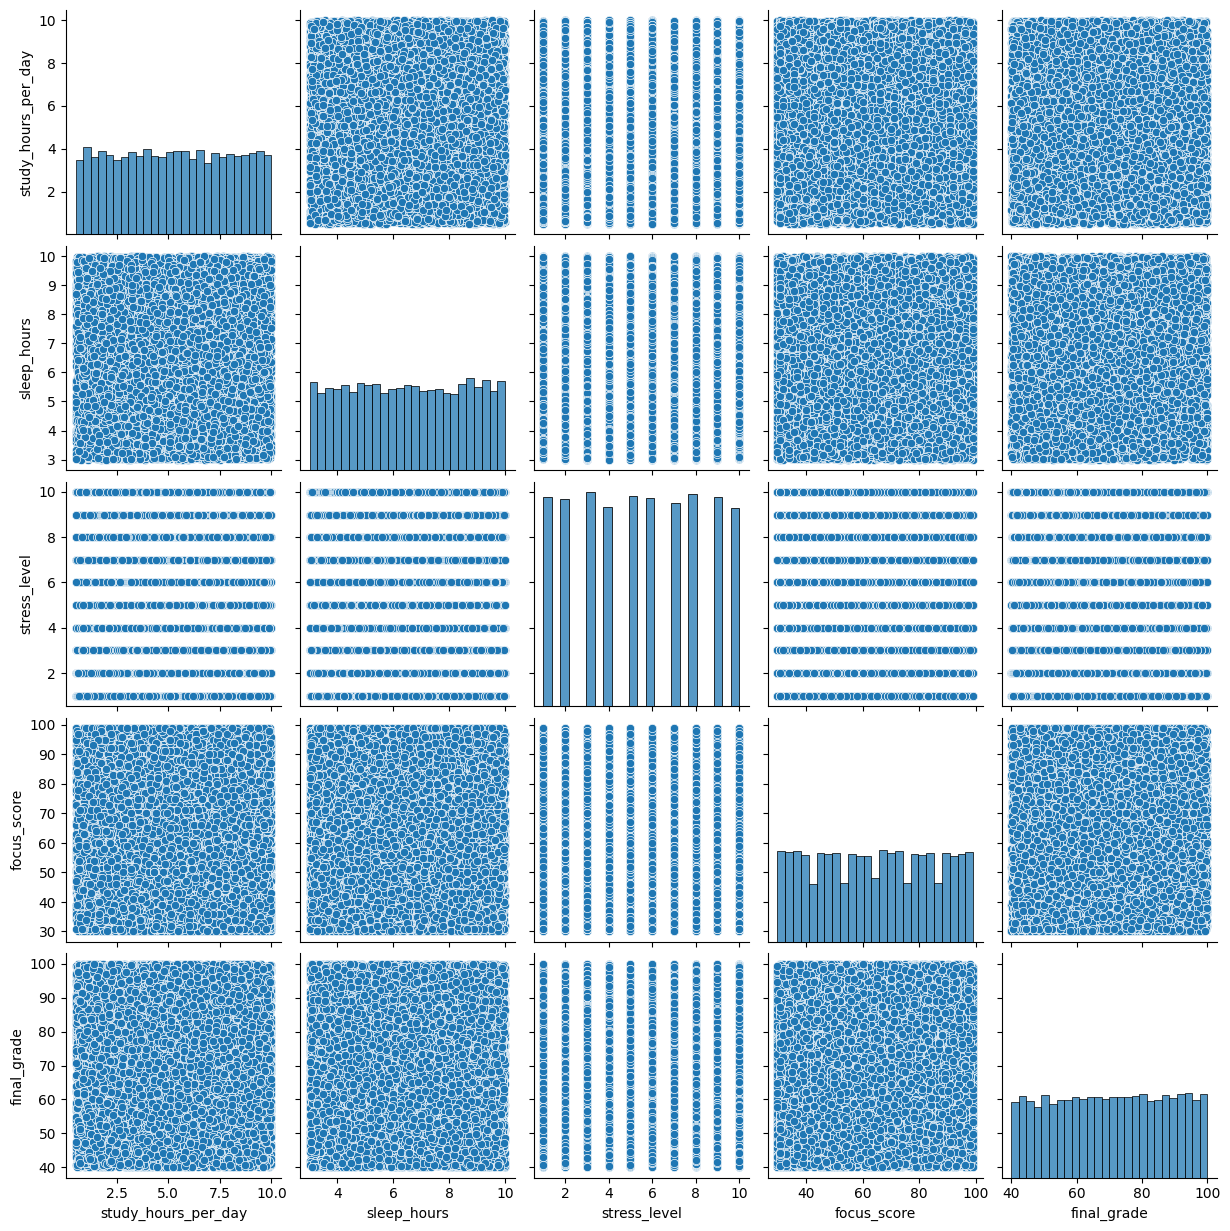

In [64]:
sns.pairplot(df[['study_hours_per_day', 'sleep_hours', 'stress_level', 'focus_score', 'final_grade']])
plt.show()

In [65]:
narx = df['final_grade']
n = len(narx)
mean = narx.mean()
se = stats.sem(narx)   # standart xato


print(se)

# 95% ishonch oralig'i
ci = stats.t.interval(0.95, n-1,
                      mean, se)
print(f'{mean:.1f}  CI={ci}')

0.13671585604599276
70.4  CI=(np.float64(70.10909282281645), np.float64(70.64504967718358))
